In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [4]:
x,y=make_blobs(
    n_samples=1000,
    n_features=2,
    random_state=42,
    centers=4
)

In [5]:
x

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

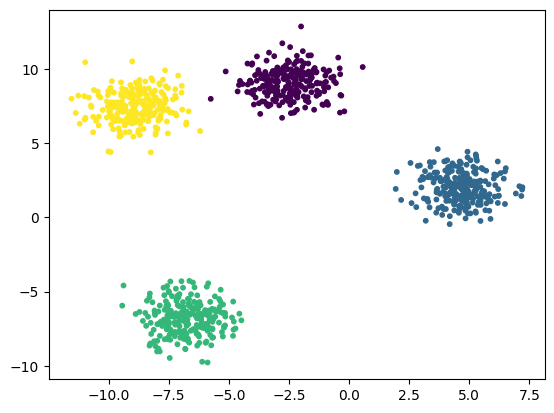

In [16]:
plt.scatter(x=x[:,0],y=x[:,1],c=y,s=10)

In [7]:
from sklearn.cluster import KMeans

In [9]:
kmeans=KMeans(
    n_clusters=4,random_state=42
)

In [12]:
labels=kmeans.fit_predict(x)

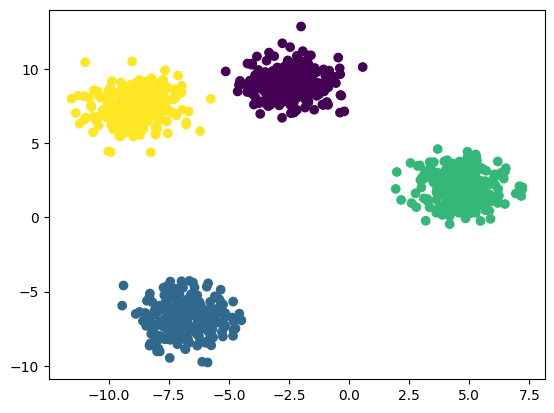

In [14]:
plt.scatter(x=x[:,0],y=x[:,1],c=labels)

## choosing k
### elbow method

In [18]:
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)
print(wcss)

[66908.2849051687, 45166.22936887345, 7324.560564741559, 1948.7329193856833, 1773.9443771229517, 1615.2074850407791, 1448.391560730009, 1362.0346185134624, 1172.4803550020613, 1047.013512983528, 1031.963872423927, 946.7082267318339, 833.6870493287837, 792.4280772403401, 739.0201731085831, 714.9740511163329, 681.2356947757821, 624.6333166041131, 612.6066073298701, 576.3045945575832]


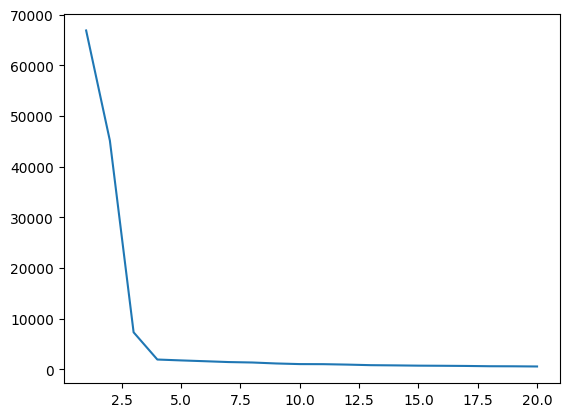

In [21]:
plt.plot(range(1,21),wcss)

### kneed module

In [22]:
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from kneed import KneeLocator

In [27]:
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
print("optimal K: ",knee.elbow)

optimal K:  4


### silhouette score

In [28]:
from sklearn.metrics import silhouette_score 

In [32]:
ss=[]
for K in range(2,21):
    kmeans=KMeans(n_clusters=K)
    labels=kmeans.fit_predict(x)
    score=silhouette_score(x,labels)
    ss.append(score)
    

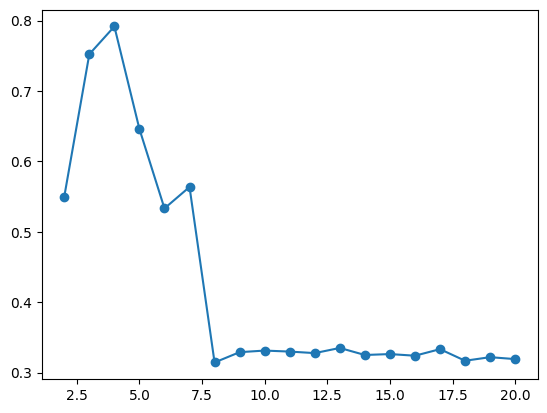

In [34]:
plt.plot(range(2,21),ss,marker="o")